## sales data analysis project

## Business Objective

The goal of this project is to analyze sales data to identify trends, sales performance, customer behavior, and business insights

## import libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## read the dataset

In [5]:
df=pd.read_csv('sales.csv')

## display the first 5 rows

In [6]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


## show dataset information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


## check missing values

In [40]:
df.isnull().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
Profit                  0
Month                   0
dtype: int64

## Group sales by region

In [41]:
df.groupby('Region')['Sales_Amount'].sum()

Region
East     1259792.93
North    1369612.51
South    1154250.86
West     1235608.93
Name: Sales_Amount, dtype: float64

## create a bar cgart for sales bt region

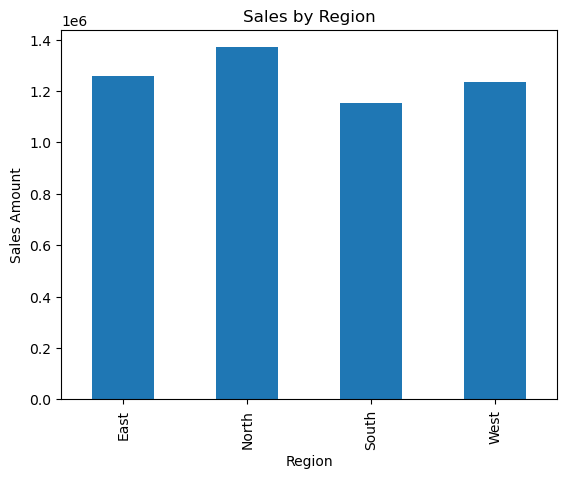

In [45]:
Region=df.groupby('Region')['Sales_Amount'].sum()
Region.plot(kind='bar')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales Amount')

plt.show()

## Insight

The north region generated the highest sales compared to other regions, indicating strong market performance in that area.

## group sales by product category

In [47]:
Product_Category=df.groupby('Product_Category')['Sales_Amount'].sum()
print(Product_Category)

Product_Category
Clothing       1313474.36
Electronics    1243499.64
Food           1201773.54
Furniture      1260517.69
Name: Sales_Amount, dtype: float64


## create bar chart for Product_Category

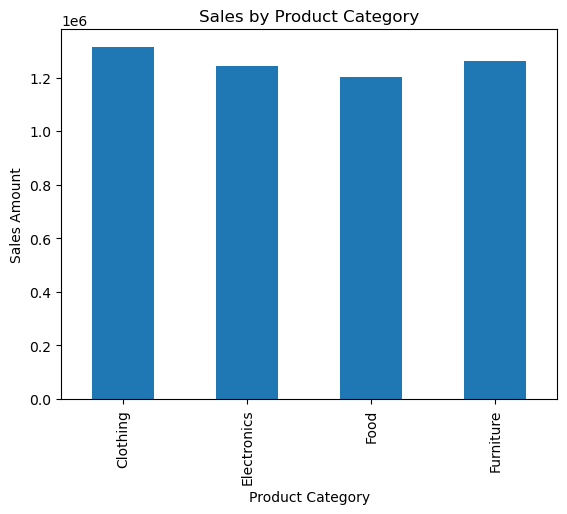

In [49]:
Product_Category=df.groupby('Product_Category')['Sales_Amount'].sum()
Product_Category.plot(kind='bar')

plt.title('Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Sales Amount')

plt.show()

## Insight

Certain product categories contributed more to total sales, indicating higher customer demand for these products.

## Group by sales repesentative 

In [11]:
df.groupby('Sales_Rep')['Sales_Amount'].sum()

Sales_Rep
Alice       965541.77
Bob        1080990.63
Charlie     860811.48
David      1141737.36
Eve         970183.99
Name: Sales_Amount, dtype: float64

## cerate bar chart for sales repesentative

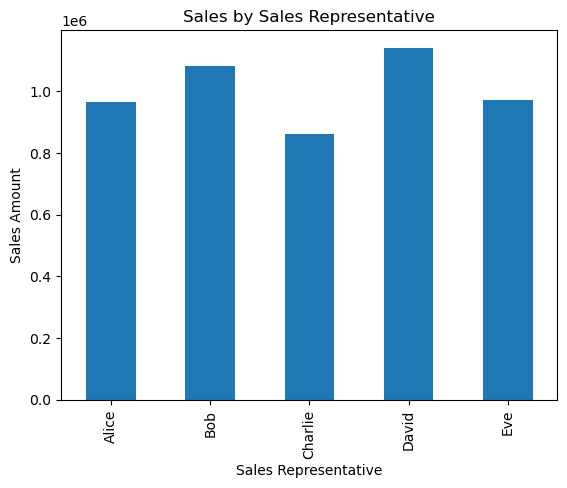

In [21]:
sales_rep=df.groupby('Sales_Rep')['Sales_Amount'].sum()
sales_rep.plot(kind='bar')

plt.title('Sales by Sales Representative')
plt.xlabel('Sales Representative')
plt.ylabel('Sales Amount')

plt.show()

## Insight

Some sales representatives achieved significantly higher sales than others, showing differences in sales performance and effectiveness.

## count Payment_Method

In [52]:
df['Payment_Method'].value_counts()

Payment_Method
Credit Card      345
Bank Transfer    342
Cash             313
Name: count, dtype: int64

## create bar chart for Payment_Method

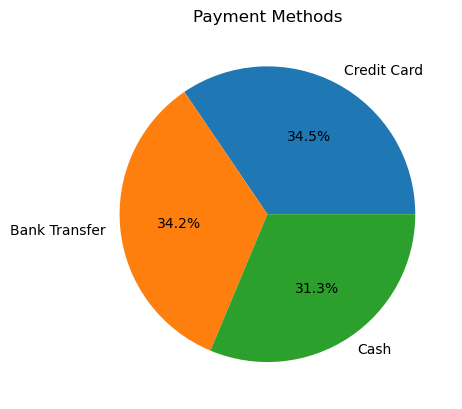

In [27]:
Payment_Method=df['Payment_Method'].value_counts()
Payment_Method.plot(kind='pie', autopct='%1.1f%%')

plt.title('Payment Methods')

plt.ylabel('')

plt.show()

## Insight

Customers showed clear preferences for specific payment methods, which may help improve payment strategies and customer experience.

## group sales by sales channel

In [14]:
df.groupby('Sales_Channel')['Sales_Amount'].sum()

Sales_Channel
Online    2458833.93
Retail    2560431.30
Name: Sales_Amount, dtype: float64

## create bar chart for sales channel

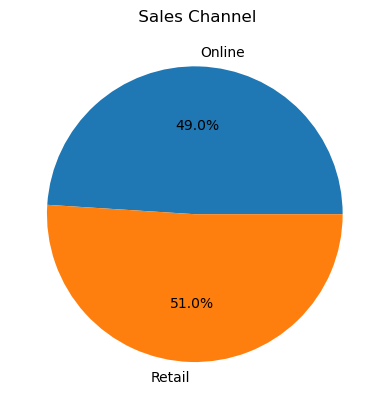

In [53]:
Sales_Channel=df.groupby('Sales_Channel')['Sales_Amount'].sum()

Sales_Channel.plot(kind='pie', autopct='%1.1f%%')

plt.title(' Sales Channel')

plt.ylabel('')

plt.show()

## Insight

One sales channel generated more revenue than the others, suggesting that customers prefer that purchasing channel.

## calculate profit

In [31]:
df['Profit'] = (df['Unit_Price'] - df['Unit_Cost']) * df['Quantity_Sold']

## group profit by Region

In [32]:
profit_region = df.groupby('Region')['Profit'].sum()
print(profit_region)

Region
East     1650557.20
North    1661461.20
South    1519736.90
West     1656091.77
Name: Profit, dtype: float64


## create bar chart for profit by Region

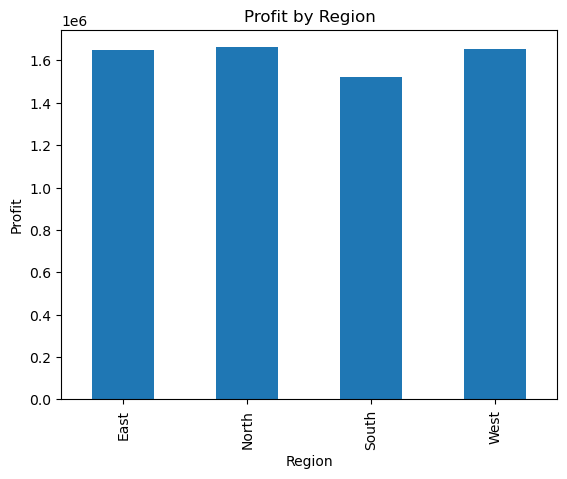

In [33]:
profit_region.plot(kind='bar')

plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')

plt.show()

## Insight

Profit varied across regions, indicating differences in operational efficiency and sales profitability.

In [ ]:
## Convert sale date to datetime
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

In [35]:
# Extract month from sale date
df['Month'] = df['Sale_Date'].dt.month

In [36]:
# Group sales by month
monthly_sales = df.groupby('Month')['Sales_Amount'].sum()

# Display monthly sales
print(monthly_sales)

Month
1     495420.37
2     368919.36
3     402638.77
4     438992.61
5     389078.76
6     418458.34
7     374242.88
8     443171.28
9     367837.60
10    460378.78
11    467482.90
12    392643.58
Name: Sales_Amount, dtype: float64


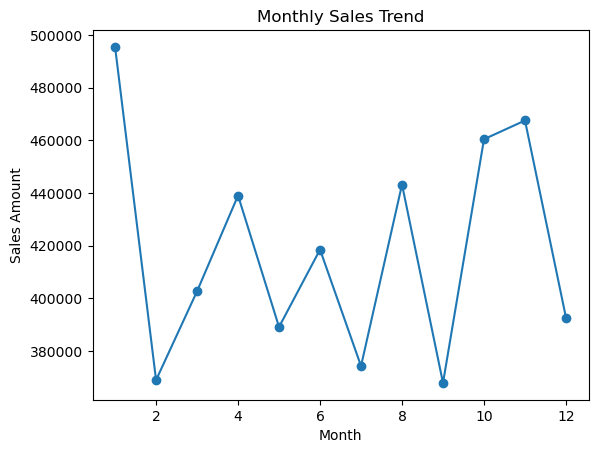

In [37]:
# Create line chart for monthly sales
monthly_sales.plot(kind='line', marker='o')

# Add chart title and labels
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales Amount')

# Display chart
plt.show()

## Insight

Sales increased during the middle months of the year and declined slightly toward the end, showing seasonal fluctuations in customer demand.

## Insight

Higher sales volumes did not always result in higher profits, suggesting that discounts and costs may impact profitability.

## Insight

The analysis revealed valuable business patterns that can support better decision-making and future sales planning.

## Executive Summary: Monthly Sales Performance
The Big Win: January is the top-performing month, peaking near 500,000 in sales, followed closely by a strong Q4 recovery in November (~470,000).
The Major Bottleneck: Sales crash instantly in February to the lowest point of the year (~370,000).
The Pattern: A volatile "zigzag" fluctuation occurs between months 2 and 9, with sales regularly rising in even months and dropping in odd months.
 Project Recommendations
Stabilize February: Launch targeted promotional campaigns to prevent the post-January revenue drop.
Capitalize on the Zigzag: Align marketing budgets and inventory restocks with the alternating bi-monthly demand.

# Conclusion 

This project analyzed sales data to identify business trends, customer behavior, sales performance, and profitability across regions and sales channels.

The analysis showed noticeable variations in sales and profit performance between regions, product categories, and sales channels. Seasonal fluctuations were also identified through monthly sales trend analysis.


# Recommendations 

- Focus marketing efforts on high-performing regions.
- Improve strategies in low-performing months.
- Increase inventory for high-demand product categories.
- Optimize pricing and discount strategies to improve profitability.
- Analyze customer preferences to improve sales channels and payment methods.
